In [1]:
#import math
import numpy as np
#import dateutil as du
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

import modules.URLhandler as URLhandler
#import modules.feelsLikeCalc as fLCalc
import modules.timeHandler as timeHandler

In [2]:
# Rounding is performed because the API can't handle precision higher than 4 places.
#lat = round(float(input("Enter the latitude of the city (e.g. Ames: 42.00, KOWA: 44.12):")), 4)
#lon = round(float(input("Enter the longitude of the city (e.g. Ames: -93.62, KOWA: -93.26):")), 4)

# Lynchburg, VA [KLYH]:
#lat = 37.3208
#lon = -79.2067

# Ames:
lat = 42.0347
lon = -93.6199

In [3]:
# Base of the URL used for the OpenMeteo API.
api_URL_base = "https://api.open-meteo.com/v1/forecast"

# Names of the variables requested from the API.
variableNames = "&hourly=temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,cloud_cover,wind_speed_10m,wind_direction_10m,rain,snowfall"

# Names of the units the variables should be in.
variableUnits = "&temperature_unit=fahrenheit&wind_speed_unit=mph&precipitation_unit=inch"

# Enter in the number of forecast days. Must be an integer between 1 and 16.
forecastDays = str(int(7))

# Combines the above variables.
api_URL_common = api_URL_base + "?latitude=" + str(lat) + "&longitude=" + str(lon) + variableNames + variableUnits + "&forecast_days=" + forecastDays

In [4]:
api_URL_NOAA = api_URL_common + "&models=gfs_global,gfs_hrrr,ncep_nbm_conus,gfs_graphcast025"

dataNOAA = URLhandler.URLcollectorJSON(api_URL_NOAA, "NOAA forecast data")

In [5]:
api_URL_ECMWF = api_URL_common + "&models=ecmwf_ifs025,ecmwf_aifs025"

dataECMWF = URLhandler.URLcollectorJSON(api_URL_ECMWF, "ECMWF forecast data")

In [6]:
api_URL_GEM = api_URL_common + "&models=gem_global,gem_regional,gem_hrdps_continental"

dataGEM = URLhandler.URLcollectorJSON(api_URL_GEM, "GEM forecast data")

In [7]:
NOAAdataLength = len(dataNOAA['hourly']['time'])

In [8]:
# Naming here makes it much easier to handle in the event I want to change the names.
modelName = "modelName"
timeName = "timestamp"
temperatureName = "temperature"
dewpointName = "dewpoint"
rhName = "relativeHumidity"
feelsLikeName = "apparentTemp"
cloudCoverName = "cloudCover"
windDirName = "windDirection"
windSpeedName = "windSpeed"
rainName = "rainfall"
snowName = "snowfall"
rainTotalName = "rainTotals"
snowTotalName = "snowTotals"
colorName = "lineColor"
linewidthName = "linewidth"

In [9]:
# Common dictionary format for all forecasts.
# modelName, colorName, and linewidthName are identical for all values.
dictForecast = {modelName:       [None]*NOAAdataLength,
                timeName:        [None]*NOAAdataLength,
                temperatureName: [None]*NOAAdataLength,
                dewpointName:    [None]*NOAAdataLength,
                rhName:          [None]*NOAAdataLength,
                feelsLikeName:   [None]*NOAAdataLength,
                cloudCoverName:  [None]*NOAAdataLength,
                windDirName:     [None]*NOAAdataLength,
                windSpeedName:   [None]*NOAAdataLength,
                rainName:        [None]*NOAAdataLength,
                snowName:        [None]*NOAAdataLength,
                rainTotalName:   [None]*NOAAdataLength,
                snowTotalName:   [None]*NOAAdataLength,
                colorName:       [None]*NOAAdataLength,
                linewidthName:   [None]*NOAAdataLength}

# Creates the data frames that are used for storing model data.
GFSdataframe = pd.DataFrame(dictForecast)
GFS_GCdataframe = pd.DataFrame(dictForecast)
HRRRdataframe = pd.DataFrame(dictForecast)
NBMdataframe = pd.DataFrame(dictForecast)

ECMWFdataframe = pd.DataFrame(dictForecast)
ECMWF_AIdataframe = pd.DataFrame(dictForecast)

GDPSdataframe = pd.DataFrame(dictForecast)
RDPSdataframe = pd.DataFrame(dictForecast)
HRDPSdataframe = pd.DataFrame(dictForecast)

In [ ]:
def isPrecipNull(val):
    if(val == None):
        return 0
    else:
        return val
    
# Manages the DataFrames in a singular location rather than across the program.
def dataFrameManager(dataFrameIn, dataFrameOut, modelName):
    dataFrameOut[timeName]        = dataFrameIn['hourly']['time']
    dataFrameOut[temperatureName] = dataFrameIn['hourly'][str('temperature_2m_' + modelName)]
    dataFrameOut[dewpointName]    = dataFrameIn['hourly'][str('dew_point_2m_' + modelName)]
    dataFrameOut[rhName]          = dataFrameIn['hourly'][str('relative_humidity_2m_' + modelName)]
    dataFrameOut[feelsLikeName]   = dataFrameIn['hourly'][str('apparent_temperature_' + modelName)]
    dataFrameOut[cloudCoverName]  = dataFrameIn['hourly'][str('cloud_cover_' + modelName)]
    dataFrameOut[windDirName]     = dataFrameIn['hourly'][str('wind_direction_10m_' + modelName)]
    dataFrameOut[windSpeedName]   = dataFrameIn['hourly'][str('wind_speed_10m_' + modelName)]
    # The absolute value is needed due to issues with NBM snowfall accounting.
    # See open-meteo/open-meteo issue #1237.
    dataFrameOut[rainName] = [abs(isPrecipNull(x)) for x in dataFrameIn['hourly'][str('rain_' + modelName)]]
    dataFrameOut[snowName] = [abs(isPrecipNull(x)) for x in dataFrameIn['hourly'][str('snowfall_' + modelName)]]
    # Accumulation totals.
    dataFrameOut[rainTotalName] = np.cumsum(dataFrameOut[rainName])
    dataFrameOut[snowTotalName] = np.cumsum(dataFrameOut[snowName])

    return dataFrameOut

In [11]:
# Set colors for the plots.
GFScolor = "royalblue"
GFS_GCcolor = "lightskyblue"
HRRRcolor = "forestgreen"
NBMcolor = "red"

ECMWFcolor = "xkcd:golden yellow"
ECMWF_AIcolor = "xkcd:pumpkin"

GDPScolor = "xkcd:hot purple"
RDPScolor = "xkcd:electric purple"
HRDPScolor = "xkcd:faded purple"

linewidth = 0.80
NBMlinewidth = 1.25

In [ ]:
# First checks if the data exists in the DataFrame then runs the data frame manager if so,
# then converts the timestamps into a usable format.
# Finally sets the name, line color, and line width for each.
if('temperature_2m_gfs_global' in dataNOAA['hourly']):
    GFSdataframe = dataFrameManager(dataNOAA, GFSdataframe, 'gfs_global')
    GFSdataframe[timeName] = timeHandler.timeParser(GFSdataframe[timeName])
    GFSdataframe[modelName] = "GFS"
    GFSdataframe[colorName] = GFScolor
    GFSdataframe[linewidthName] = linewidth
    
if('temperature_2m_gfs_graphcast025' in dataNOAA['hourly']):
    GFS_GCdataframe = dataFrameManager(dataNOAA, GFS_GCdataframe, 'gfs_graphcast025')
    GFS_GCdataframe[timeName] = timeHandler.timeParser(GFS_GCdataframe[timeName])
    GFS_GCdataframe[modelName] = "Graphcast"
    GFS_GCdataframe[colorName] = GFS_GCcolor
    GFS_GCdataframe[linewidthName] = linewidth

if('temperature_2m_gfs_hrrr' in dataNOAA['hourly']):
    HRRRdataframe = dataFrameManager(dataNOAA, HRRRdataframe, 'gfs_hrrr')
    HRRRdataframe[timeName] = timeHandler.timeParser(HRRRdataframe[timeName])
    HRRRdataframe[modelName] = "HRRR"
    HRRRdataframe[colorName] = HRRRcolor
    HRRRdataframe[linewidthName] = linewidth

if('temperature_2m_ncep_nbm_conus' in dataNOAA['hourly']):
    NBMdataframe = dataFrameManager(dataNOAA, NBMdataframe, 'ncep_nbm_conus')
    NBMdataframe[timeName] = timeHandler.timeParser(NBMdataframe[timeName])
    NBMdataframe[modelName] = "NBM"
    NBMdataframe[colorName] = NBMcolor
    NBMdataframe[linewidthName] = NBMlinewidth

In [13]:
# First checks if the data exists in the dataframe then runs the data frame manager if so,
# then converts the timestamps into a usable format.
# Finally sets the name, line color, and line width for each.
if('temperature_2m_ecmwf_ifs025' in dataECMWF['hourly']):
    ECMWFdataframe = dataFrameManager(dataECMWF, ECMWFdataframe, 'ecmwf_ifs025')
    ECMWFdataframe[timeName] = timeHandler.timeParser(ECMWFdataframe[timeName])
    ECMWFdataframe[modelName] = "ECMWF"
    ECMWFdataframe[colorName] = ECMWFcolor
    ECMWFdataframe[linewidthName] = linewidth

if('temperature_2m_ecmwf_aifs025' in dataECMWF['hourly']):
    ECMWF_AIdataframe = dataFrameManager(dataECMWF, ECMWF_AIdataframe, 'ecmwf_aifs025')
    ECMWF_AIdataframe[timeName] = timeHandler.timeParser(ECMWF_AIdataframe[timeName])
    ECMWF_AIdataframe[modelName] = "ECMWF AI"
    ECMWF_AIdataframe[colorName] = ECMWF_AIcolor
    ECMWF_AIdataframe[linewidthName] = linewidth

In [14]:
# First checks if the data exists in the dataframe then runs the data frame manager if so,
# then converts the timestamps into a usable format.
# Finally sets the name, line color, and line width for each.
if('temperature_2m_gem_global' in dataGEM['hourly']):
    GDPSdataframe = dataFrameManager(dataGEM, GDPSdataframe, 'gem_global')
    GDPSdataframe[timeName] = timeHandler.timeParser(GDPSdataframe[timeName])
    GDPSdataframe[modelName] = "GPDS"
    GDPSdataframe[colorName] = GDPScolor
    GDPSdataframe[linewidthName] = linewidth

if('temperature_2m_gem_regional' in dataGEM['hourly']):
    RDPSdataframe = dataFrameManager(dataGEM, RDPSdataframe, 'gem_regional')
    RDPSdataframe[timeName] = timeHandler.timeParser(RDPSdataframe[timeName])
    RDPSdataframe[modelName] = "RDPS"
    RDPSdataframe[colorName] = RDPScolor
    RDPSdataframe[linewidthName] = linewidth

if('temperature_2m_gem_hrdps_continental' in dataGEM['hourly']):
    HRDPSdataframe = dataFrameManager(dataGEM, HRDPSdataframe, 'gem_hrdps_continental')
    HRDPSdataframe[timeName] = timeHandler.timeParser(HRDPSdataframe[timeName])
    HRDPSdataframe[modelName] = "HRDPS"
    HRDPSdataframe[colorName] = HRDPScolor
    HRDPSdataframe[linewidthName] = linewidth

In [15]:
dataFrameList = (GDPSdataframe,
                 RDPSdataframe,
                 HRDPSdataframe,
                 GFSdataframe,
                 GFS_GCdataframe,
                 HRRRdataframe,
                 ECMWFdataframe,
                 ECMWF_AIdataframe,
                 NBMdataframe)

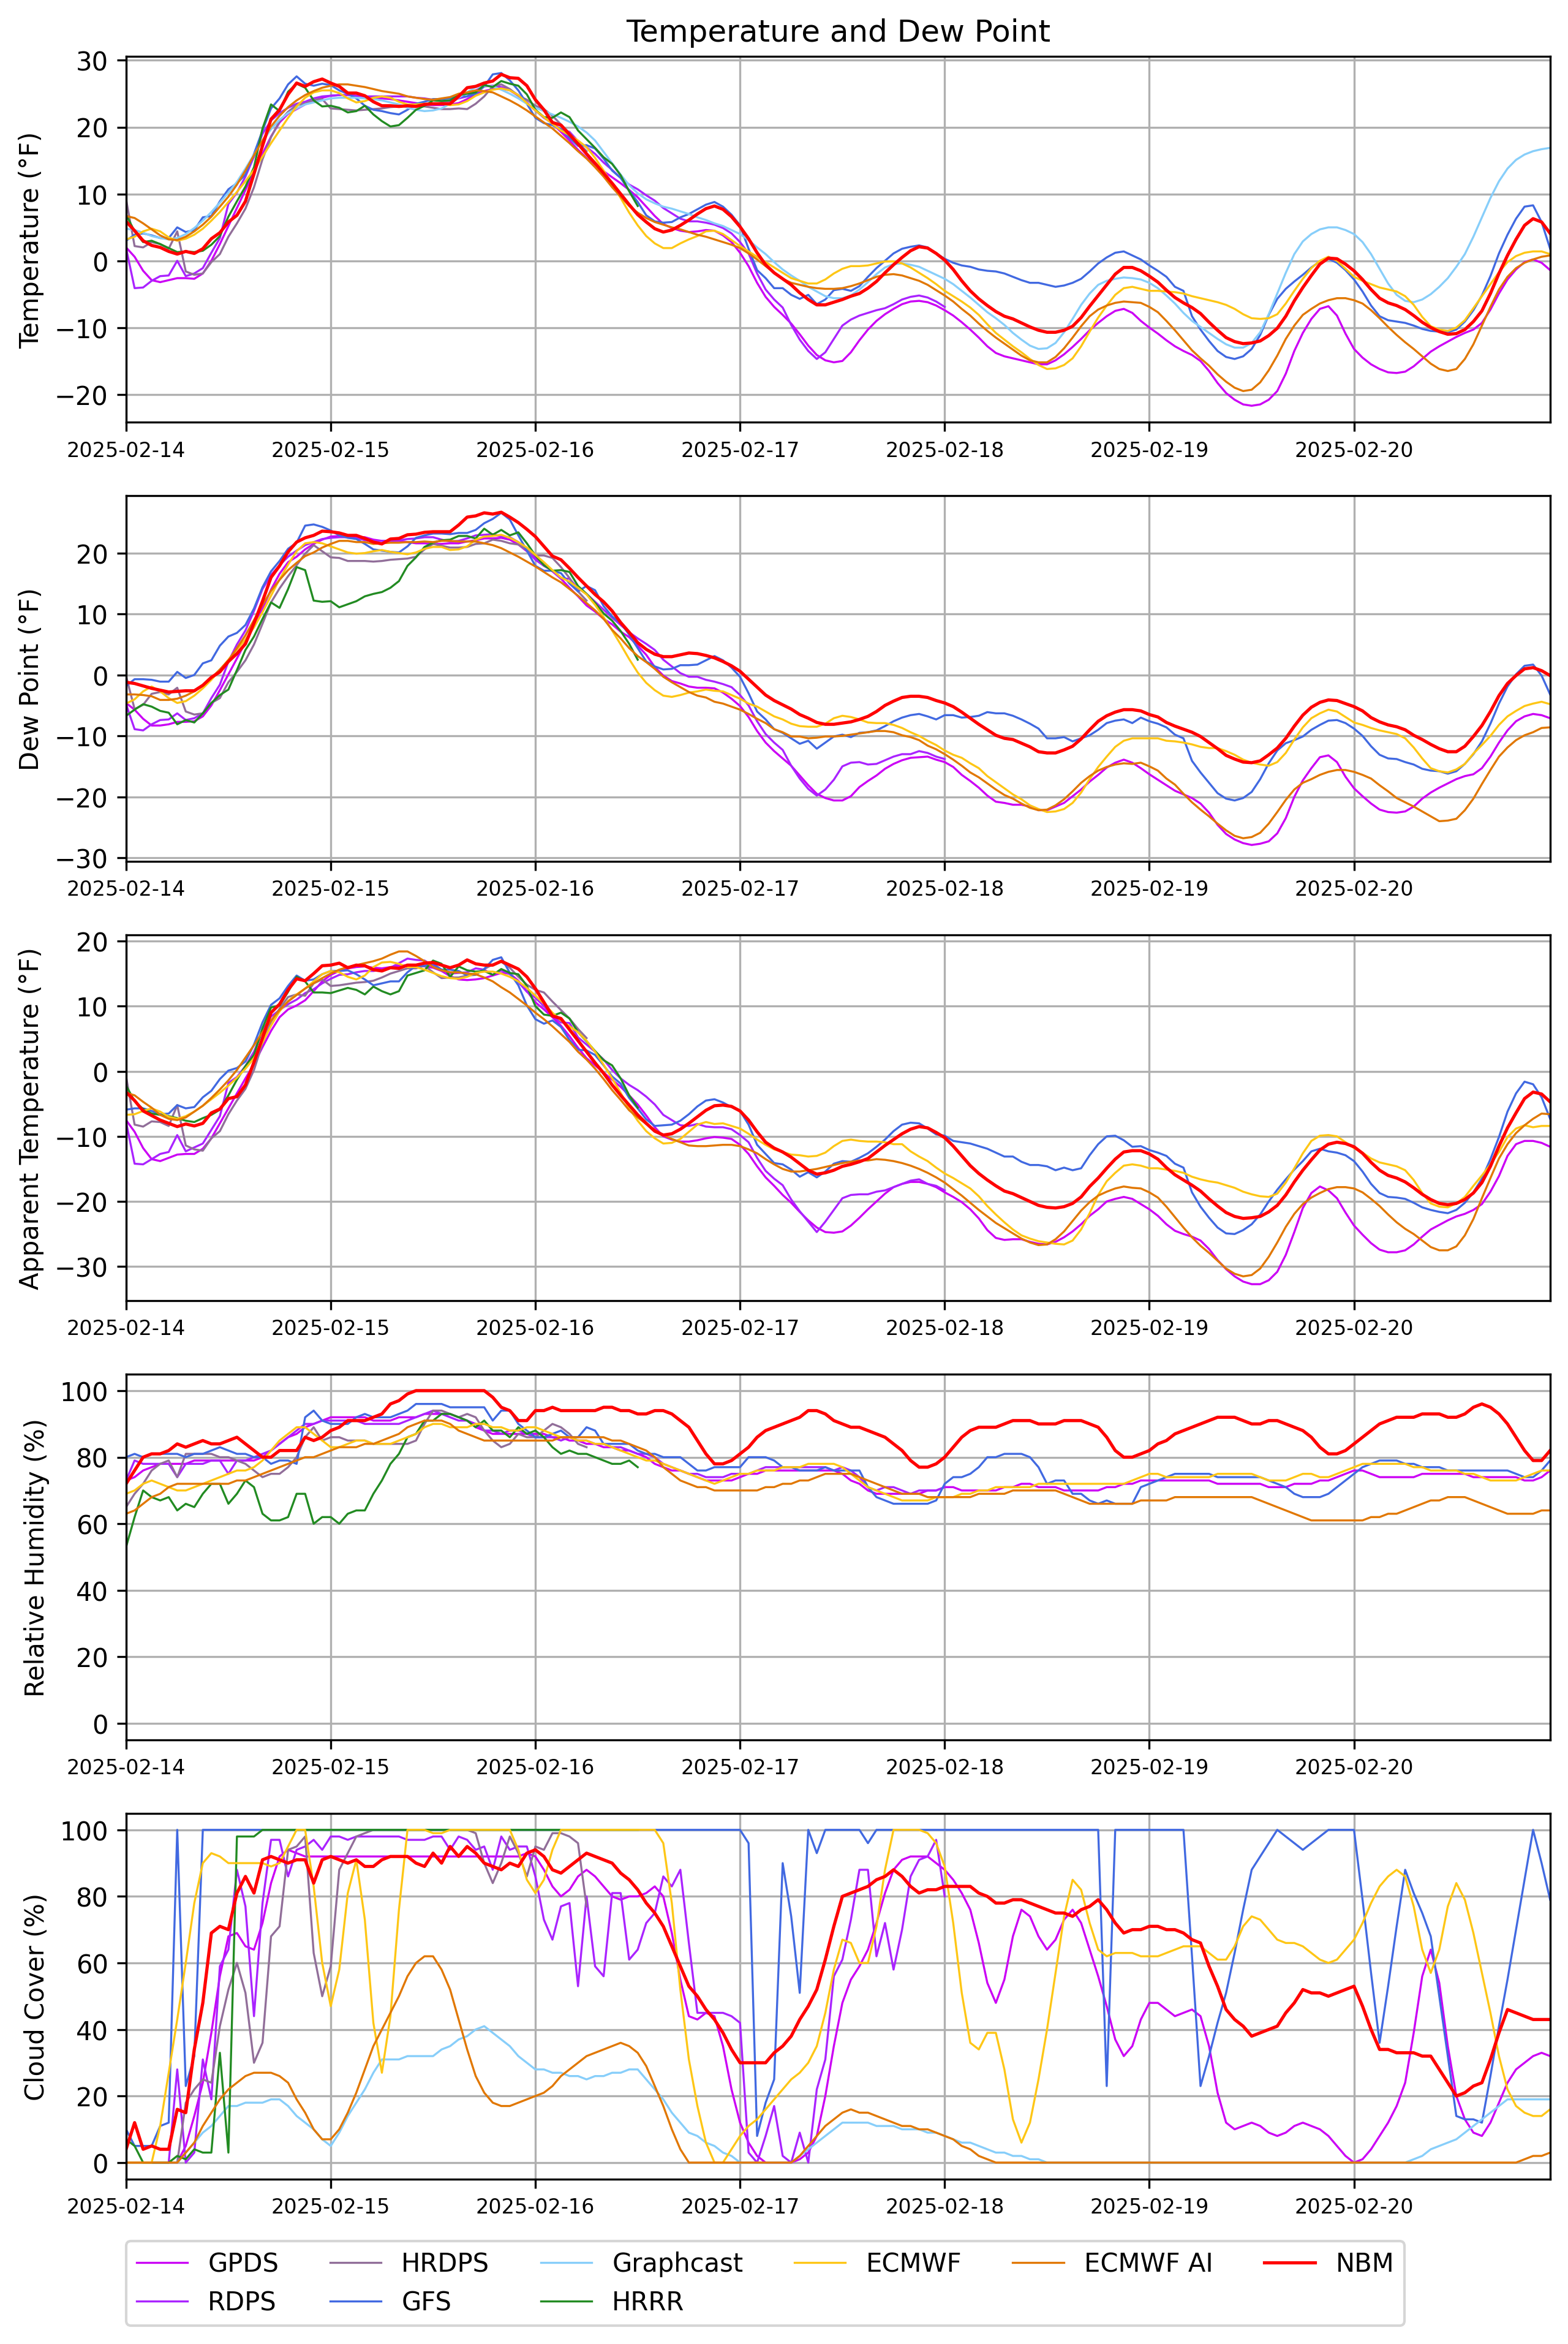

In [16]:
plt.rcParams["figure.dpi"] = 300
plt.rcParams["xtick.labelsize"] = 8
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, figsize=(10,15))

# Iterates through the list of DataFrames. Much easier to work with than listing all of them out.
# Plots 2-meter air temperatures.
for i in dataFrameList:
    ax1.plot(i[timeName], i[temperatureName], color=i[colorName][0], linewidth=i[linewidthName][0])

# Plots 2-meter dew point temperatures.
# Some models (GFS-GC) lack dew point information.
for i in dataFrameList:
    ax2.plot(i[timeName], i[dewpointName], color=i[colorName][0], linewidth=i[linewidthName][0])

# Plots 2-meter apparent ("feels like") temperatures.
# Some models (GFS-GC) lack apparent temperature information.
for i in dataFrameList:
    ax3.plot(i[timeName], i[feelsLikeName], color=i[colorName][0], linewidth=i[linewidthName][0])

# Plots 2-meter relative humidities.
# Some models (GFS-GC) lack relative humidity information.
for i in dataFrameList:
    ax4.plot(i[timeName], i[rhName], color=i[colorName][0], linewidth=i[linewidthName][0])
    
# Plots total cloud cover data.
for i in dataFrameList:
    ax5.plot(i[timeName], i[cloudCoverName], color=i[colorName][0], linewidth=i[linewidthName][0], label=i[modelName][0])

# Enables gridding.
ax1.grid(True)
ax2.grid(True)
ax3.grid(True)
ax4.grid(True)
ax5.grid(True)

# Sets y-labels and title.
ax1.set_title("Temperature and Dew Point")
ax1.set_ylabel("Temperature (°F)")
ax2.set_ylabel("Dew Point (°F)")
ax3.set_ylabel("Apparent Temperature (°F)")
ax4.set_ylabel("Relative Humidity (%)")
ax5.set_ylabel("Cloud Cover (%)")

# Adjust the bounds of the plot to make it consistent.
plt.setp(ax1, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax2, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax3, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax4, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]], ylim=[-5, 105])
plt.setp(ax5, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]], ylim=[-5, 105])

# Sets the legend and size of it.
leg = ax5.legend(loc=(0, -0.4), ncol=6)

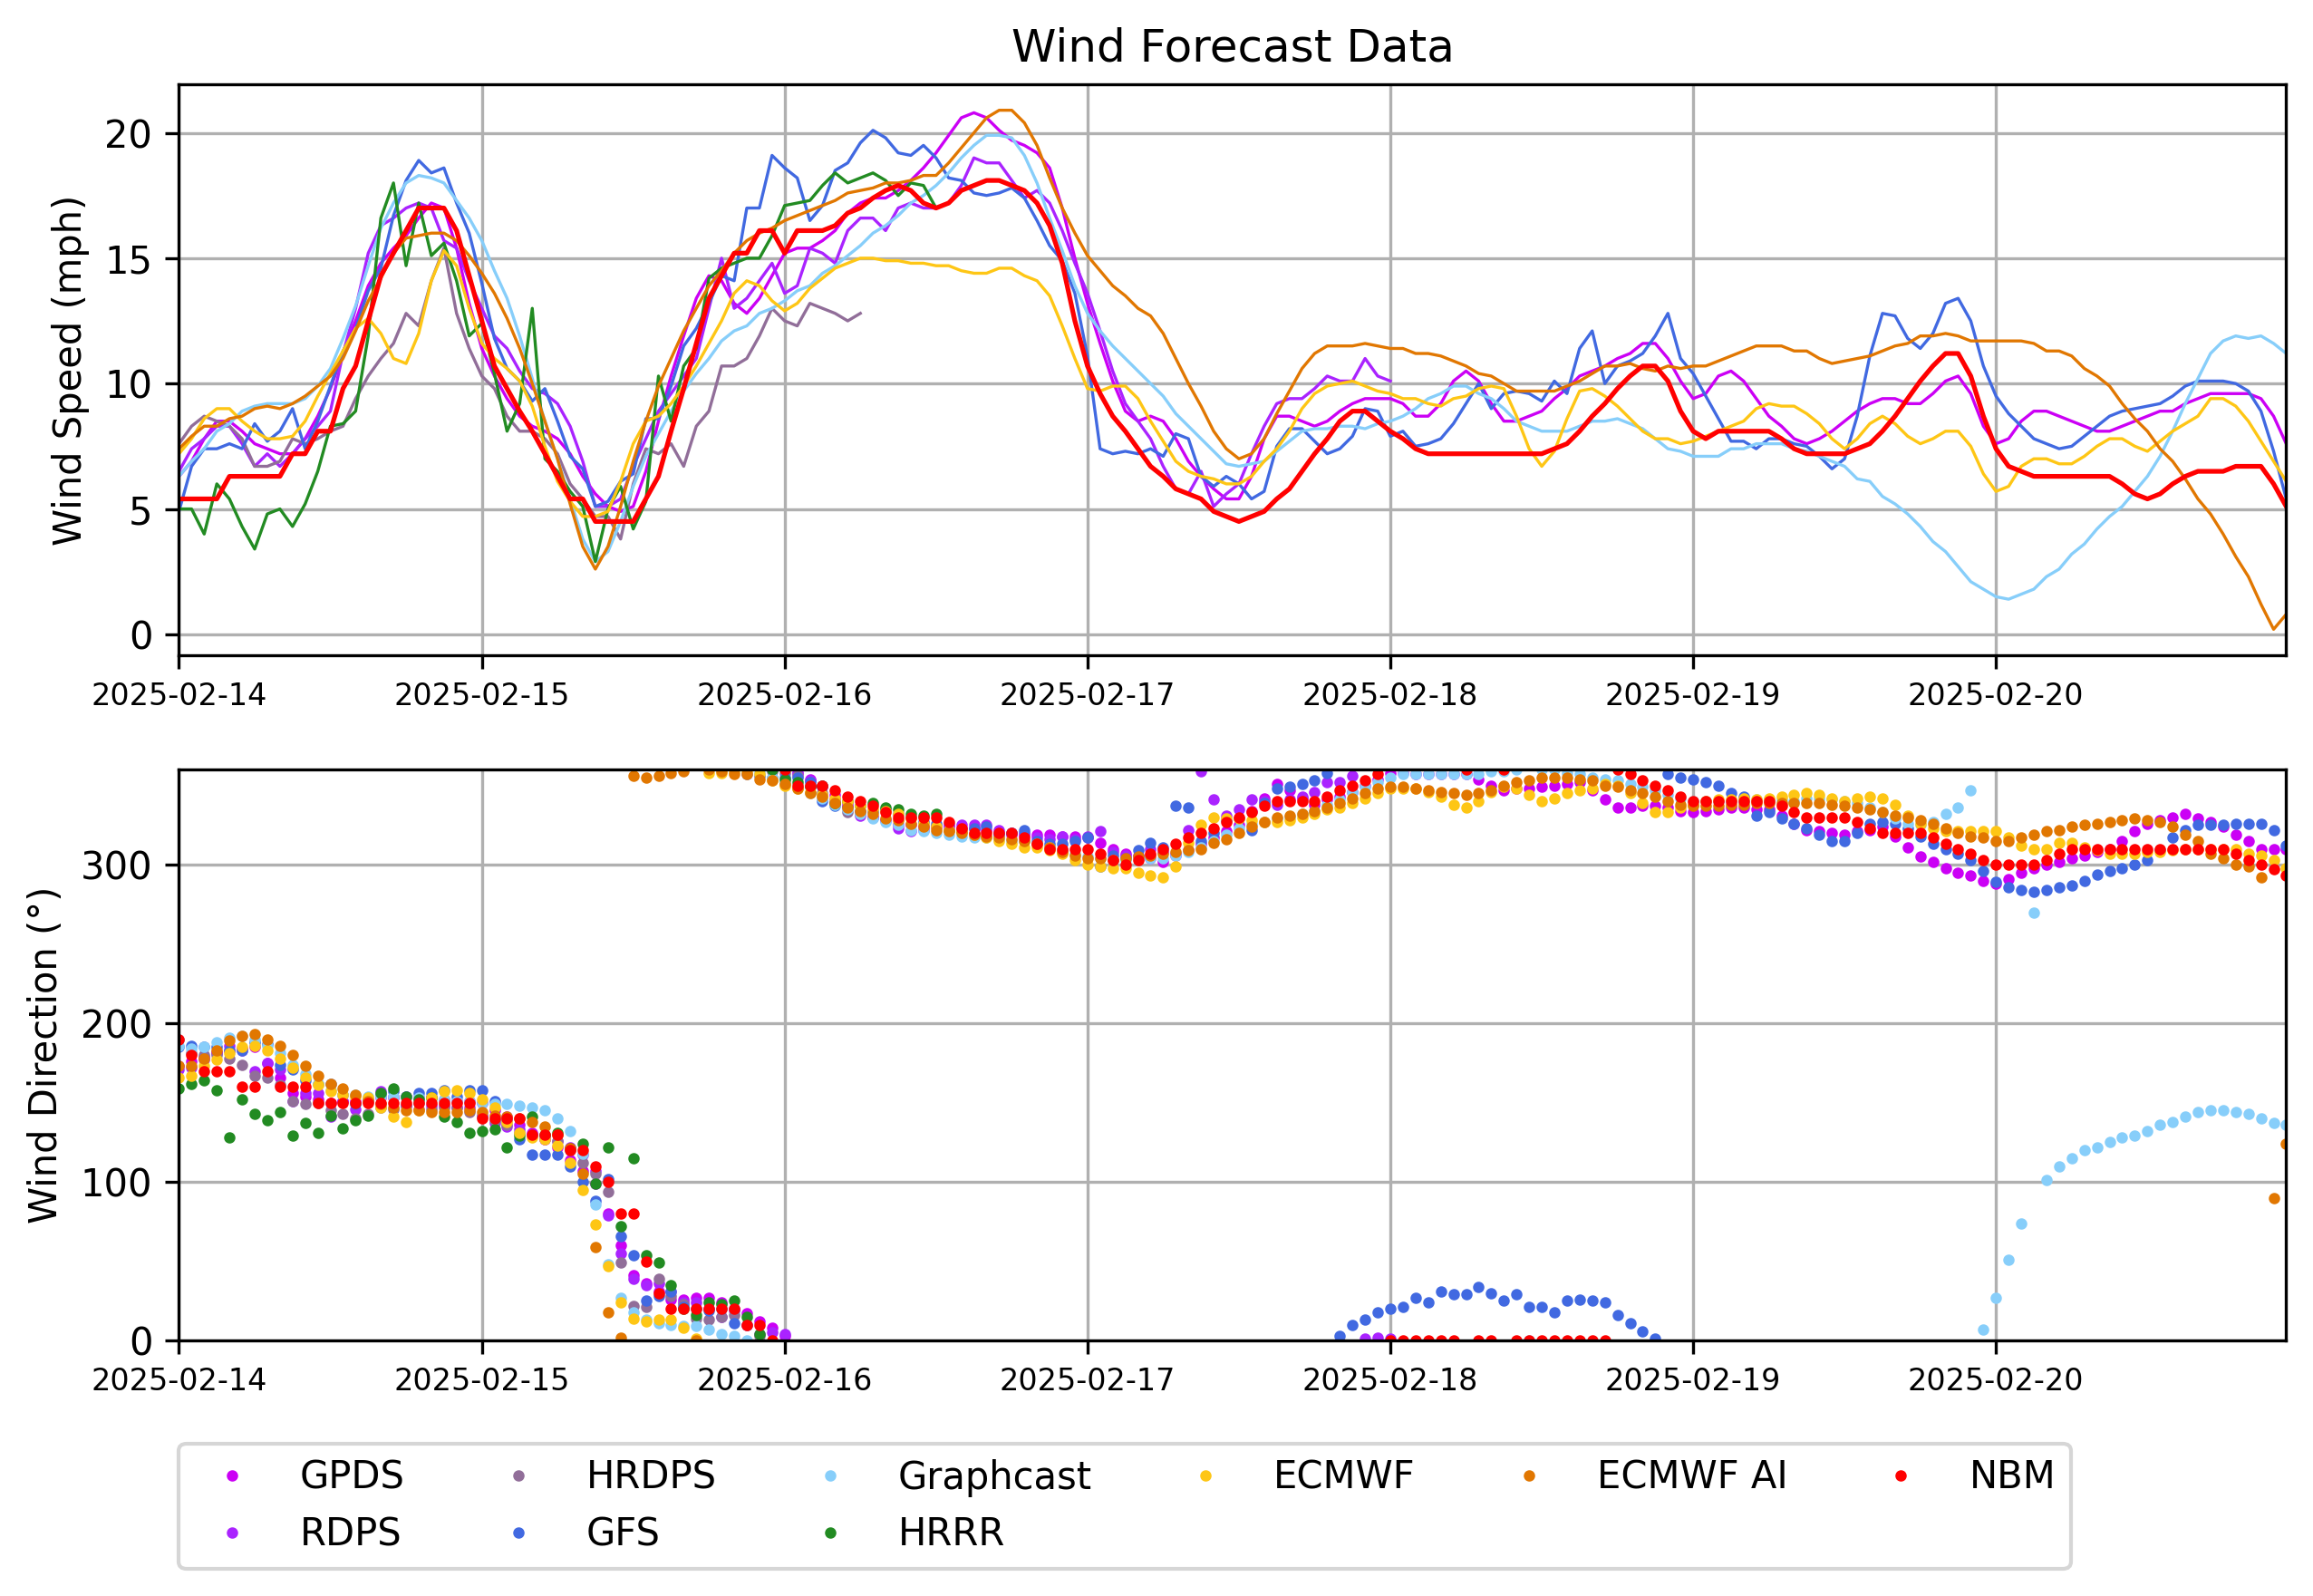

In [17]:
plt.rcParams["figure.dpi"] = 300
plt.rcParams["xtick.labelsize"] = 8
fig, (ax1, ax2) = plt.subplots(2, figsize=(10,6))

# Iterates through the list of DataFrames. Much easier to work with than listing all of them out.
# Plots wind speed information.
for i in dataFrameList:
    ax1.plot(i[timeName], i[windSpeedName], color=i[colorName][0], linewidth=i[linewidthName][0])

# Plots wind direction information.
markerStyle = dict(marker='.', markersize=4, linewidth=0)
for i in dataFrameList:
    ax2.plot(i[timeName], i[windDirName], color=i[colorName][0], **markerStyle, label=i[modelName][0])

ax1.grid(True)
ax2.grid(True)

ax1.set_title("Wind Forecast Data")
ax1.set_ylabel("Wind Speed (mph)")
ax2.set_ylabel("Wind Direction (°)")

plt.setp(ax1, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax2, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]], ylim=[0, 360])

leg = ax2.legend(loc=(0, -0.4), ncol=6)

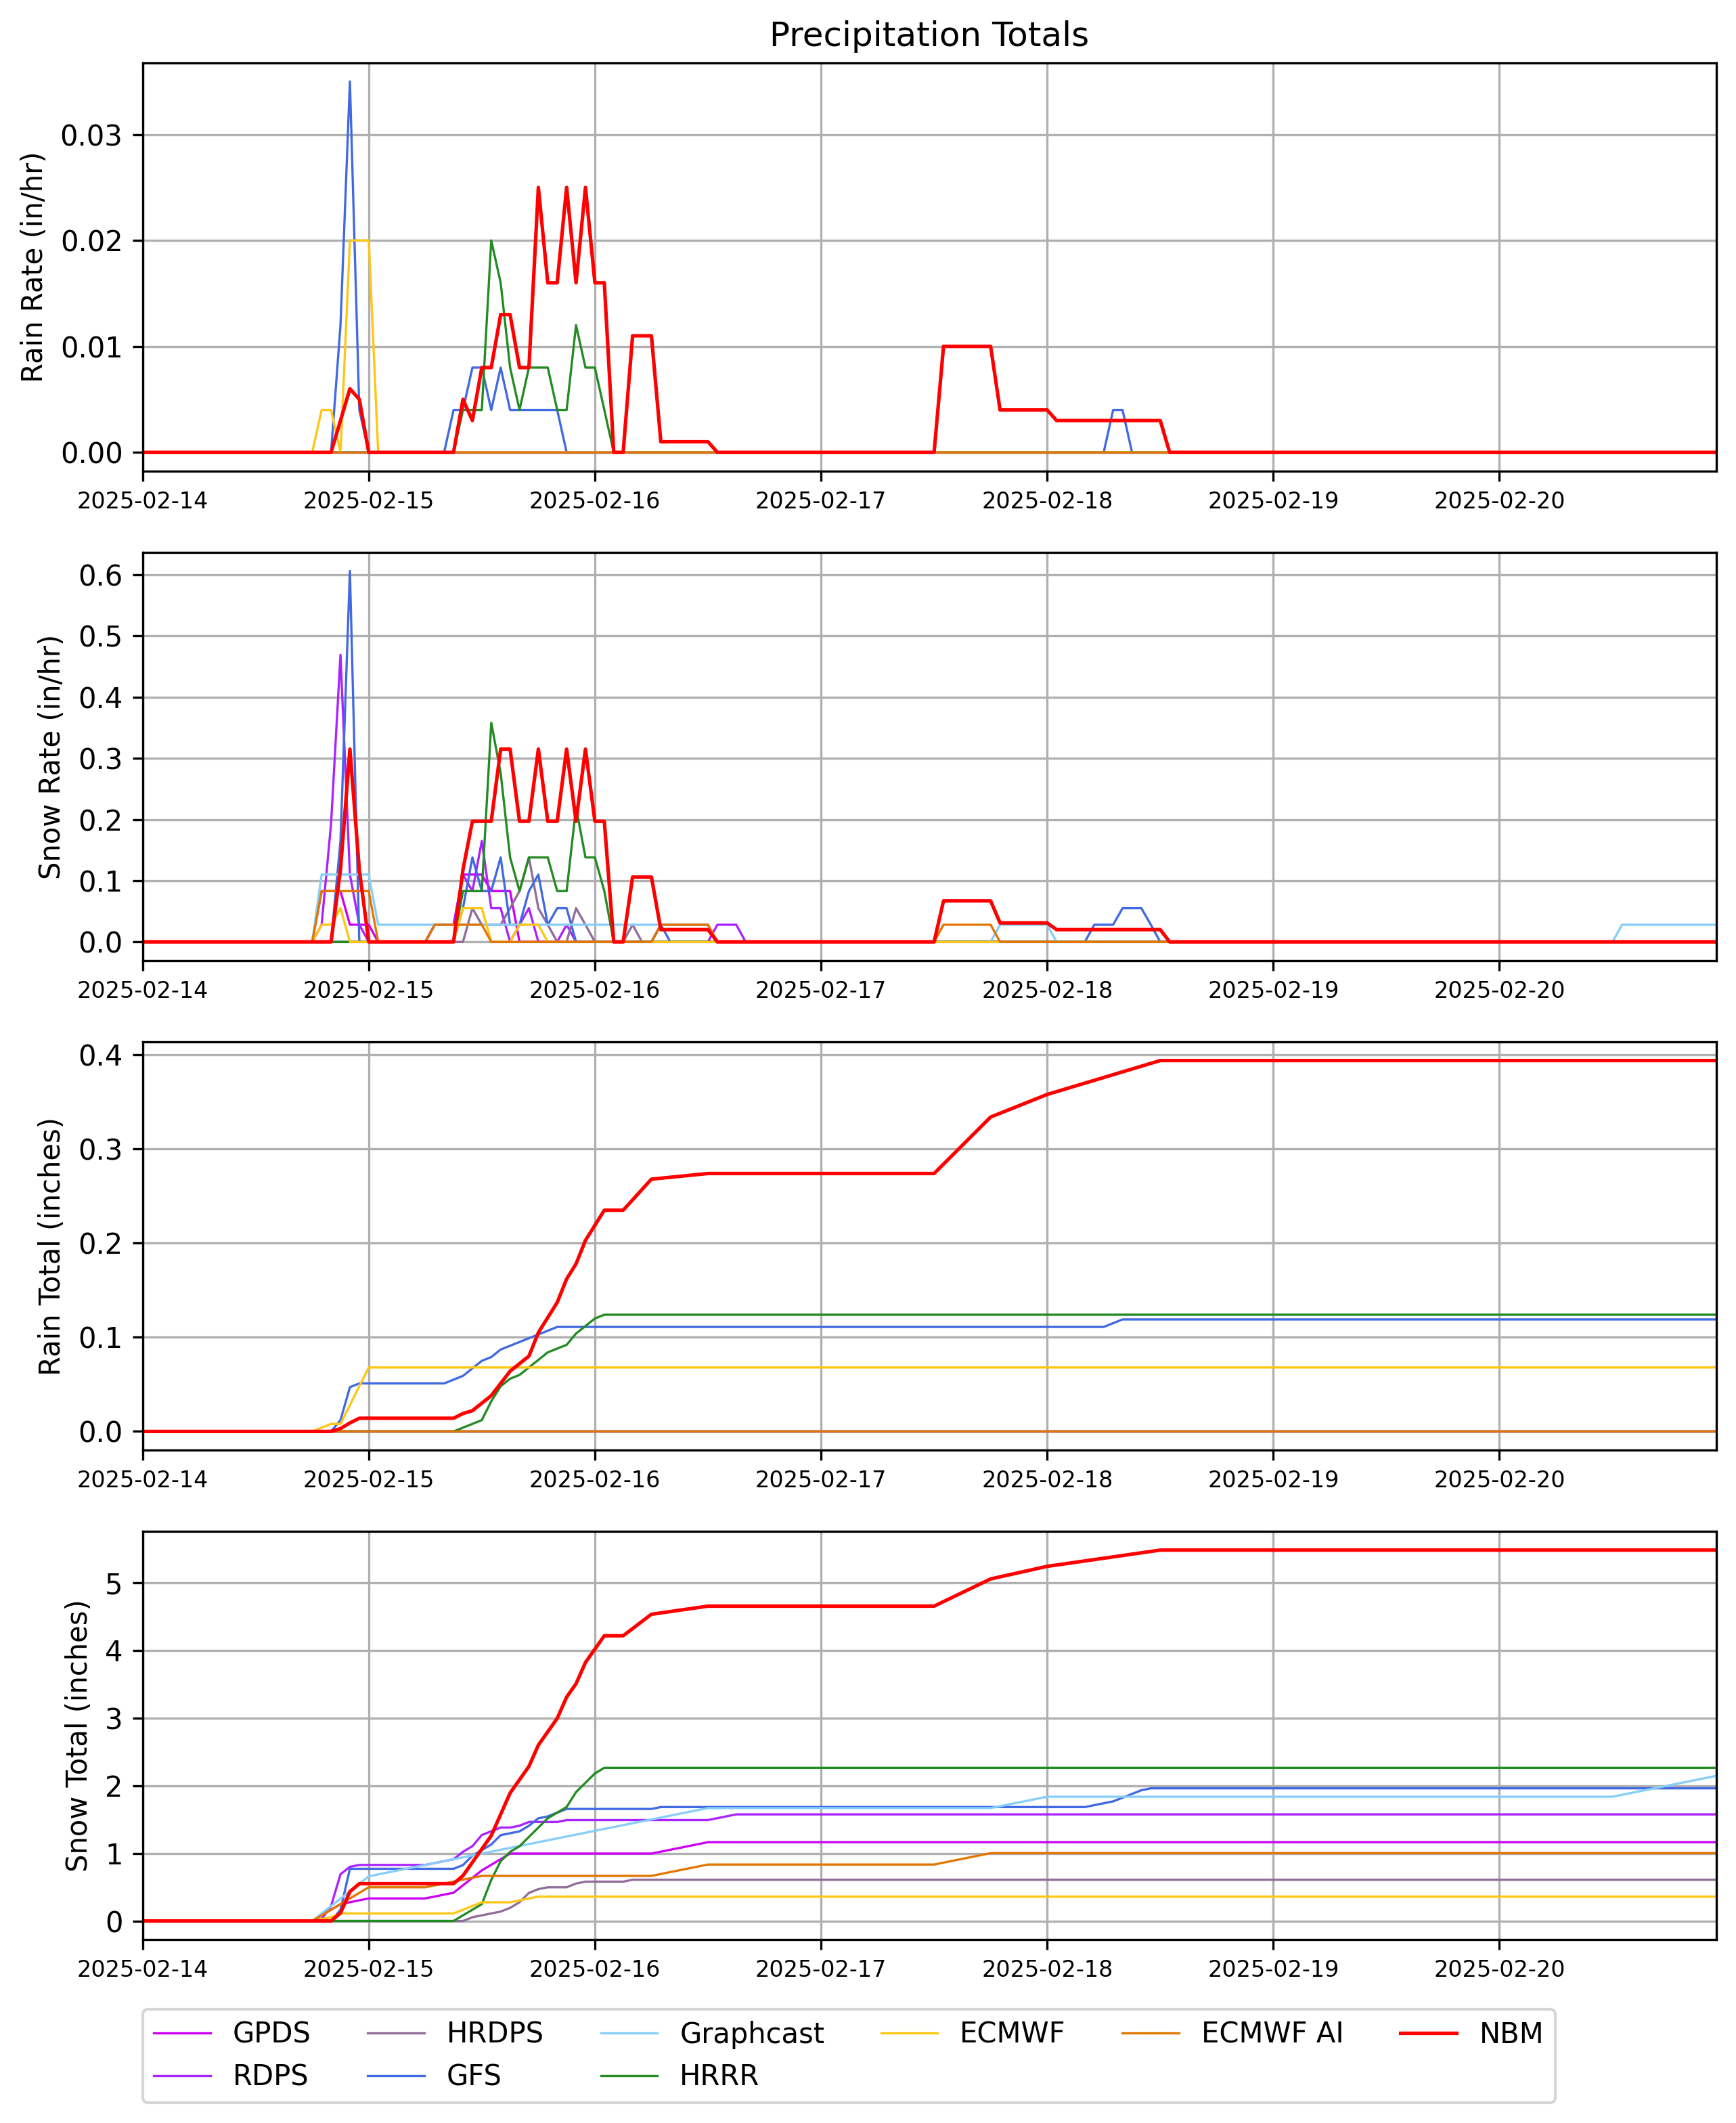

In [18]:
plt.rcParams["figure.dpi"] = 300
plt.rcParams["xtick.labelsize"] = 8
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, figsize=(10,12))

# Iterates through the list of DataFrames. Much easier to work with than listing all of them out.
# Plots rainfall rate information.
for i in dataFrameList:
    ax1.plot(i[timeName], i[rainName], color=i[colorName][0], linewidth=i[linewidthName][0])

# Plots snowfall rate information.
for i in dataFrameList:
    ax2.plot(i[timeName], i[snowName], color=i[colorName][0], linewidth=i[linewidthName][0])

# Plots rain accumulation.
for i in dataFrameList:
    ax3.plot(i[timeName], i[rainTotalName], color=i[colorName][0], linewidth=i[linewidthName][0])

# Plots snow accumulation.
for i in dataFrameList:
    ax4.plot(i[timeName], i[snowTotalName], color=i[colorName][0], linewidth=i[linewidthName][0], label=i[modelName][0])

ax1.grid(True)
ax2.grid(True)
ax3.grid(True)
ax4.grid(True)

ax1.set_title("Precipitation Totals")
ax1.set_ylabel("Rain Rate (in/hr)")
ax2.set_ylabel("Snow Rate (in/hr)")
ax3.set_ylabel("Rain Total (inches)")
ax4.set_ylabel("Snow Total (inches)")

plt.setp(ax1, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax2, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax3, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax4, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])

leg = ax4.legend(loc=(0, -0.4), ncol=6)